NM_002055
Homo sapiens glial fibrillary acidic protein (GFAP), transcript variant 1, mRNA
{'Sequence ID': 'NM_002055.5', 'Real Sequence Name': 'NM_002055', 'Sequence length': 5501, 'gc': 57.116887838574804, 'sequence': Seq('AGAGCCAGAGCAGGATGGAGAGGAGACGCATCACCTCCGCTGCTCGCCGCTCCT...TTA')}
NM_006272
Homo sapiens S100 calcium binding protein B (S100B), mRNA
{'Sequence ID': 'NM_006272.2', 'Real Sequence Name': 'NM_006272', 'Sequence length': 1135, 'gc': 53.03964757709251, 'sequence': Seq('GGGCAGAGGGAATAAGAGGCTGCCTCTGCCCACCAGTCCTGCCGCCCAGGACCC...AAG')}
NM_000484
Homo sapiens amyloid beta precursor protein (APP), transcript variant 1, mRNA
{'Sequence ID': 'NM_000484.4', 'Real Sequence Name': 'NM_000484', 'Sequence length': 3583, 'gc': 48.50683784538097, 'sequence': Seq('GTCAGTTTCCTCGGCAGCGGTAGGCGAGAGCACGCGGAGGAGCGTGCGCGGGGG...GCA')}
NM_001377265
Homo sapiens microtubule associated protein tau (MAPT), transcript variant 9, mRNA
{'Sequence ID': 'NM_001377265.1', 'Real Sequence Name': 'NM_001377

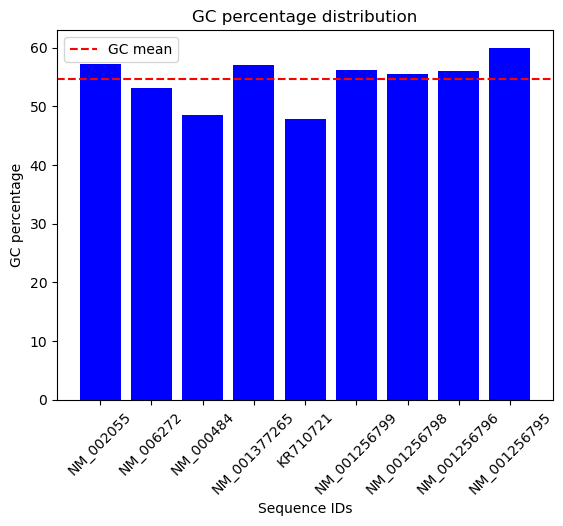

NM_002055
Homo sapiens glial fibrillary acidic protein (GFAP), transcript variant 1, mRNA


{'Sequence ID': 'NM_002055.5',
 'Real Sequence Name': 'NM_002055',
 'Sequence length': 5501,
 'gc': 57.116887838574804,
 'sequence': Seq('AGAGCCAGAGCAGGATGGAGAGGAGACGCATCACCTCCGCTGCTCGCCGCTCCT...TTA')}

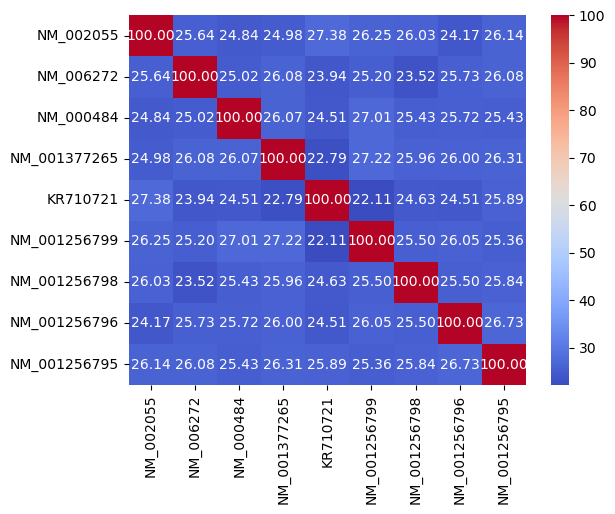

In [ ]:
from Bio import Entrez, SeqIO
import matplotlib.pyplot as plt
import time 
import numpy as np
import seaborn as sns 
import pandas as pd
Entrez.email = "diegoblancob2011@gmail.com"
genes_list = ["NM_002055.5", "NM_006272.2","NM_000484.4", "NM_001377265", "KR710721.1", "NM_198578.4", "NM_001256798.2", "NM_001256797.2", "NM_001256796.2", "NM_001256795.2"]



def gene_comparator(seq1, seq2):
    matches = 0
    for char1, char2 in zip(seq1, seq2):
        if char1 == char2:
            matches += 1
    return matches / min(len(seq1), len(seq2)) * 100

def fetch_sequence(accession_id):
    try:
        handle = Entrez.efetch(db="nucleotide", id=accession_id, rettype="gb", retmode="text")
        record = SeqIO.read(handle, "gb")
        print(record.name)
        print(record.description)
        handle.close()
        genes={
        "Sequence ID": record.id,
        "Real Sequence Name": record.name,
        "Sequence length": len(record.seq),
        "gc": (record.seq.count('G') + record.seq.count('C')) / len(record.seq) * 100,
        "sequence": record.seq
        }
        return genes
    except Exception as e:
        print(f"Error fetching sequence for {accession_id}: {e}")
        return None

def genes_loop():
    gc_list = []
    genes = [] 
    mean = 0
    average = 0
    for gene in genes_list:
        time.sleep(1.5)
        result = fetch_sequence(gene)
        if result is not None:
            genes.append(result)  
        print(result)
    for x in genes:
        gc_list.append(x["gc"])
    gc_array = np.array(gc_list)
    nombres = [x["Real Sequence Name"] for x in genes]
    mean = np.mean(gc_array)
    average = np.average(gc_array)
    plt.bar(nombres, gc_array, color='blue',)
    plt.xticks(rotation=45)
    plt.title("GC percentage distribution")
    plt.xlabel("Sequence IDs")
    plt.ylabel("GC percentage")
    plt.axhline(mean, color='red', linestyle='--', label="GC mean")
    plt.legend()
    plt.show()
    return genes, nombres


genes, nombres = genes_loop() 
matrix = np.zeros((len(genes), len(genes)))
for i in range(len(genes)):
    for j in range(len(genes)): 
         matrix[i][j] = gene_comparator(genes[i]["sequence"], genes[j]["sequence"])
gdf=pd.DataFrame(matrix, index=nombres, columns=nombres)
sns.heatmap(gdf, annot=True, fmt=".2f", cmap="coolwarm")
plt.show




fetch_sequence("NM_002055.5")


    

